# Segregation and heat

Bulding on [*Mobility patterns are associated with experienced income segregation in large US cities*](https://www.nature.com/articles/s41467-021-24899-8), we aim to understand how extreme heat relates to segregation in US cities.

* Can we measure segregation similar to [*Moro et al*](https://www.nature.com/articles/s41467-021-24899-8)?
* How does extreme heat effect segragation?
* How does it effect place segregation vs personal segregation?
* How does POI segregation change when heat changes? Which POI categories unite in the face of climate change?


In [1]:
from datetime import datetime, timedelta, date
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db, plot
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [3]:
poi_query = """
    SELECT *
    FROM pois
"""
pois = con.sql(poi_query).pl()
pois.head()

<sys>:0: UserWarning: Extension type 'geoarrow.wkb' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.


ID_STORE,POI_GEOID,CBSAFP,PERSISTENT_ID,BRAND,LOCATION_NAME,STREET_ADDRESS,CITY,REGION,ISO_COUNTRY_CODE,NAICS_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,GEOM,CELL_ID
str,str,str,str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,binary,i64
"""11484670""","""370710313042""","""16740""","""A1_CHPT""","""ChargePoint""","""ChargePoint Holdings Inc""","""203 McAdenville Rd.""","""Lowell""","""NC""","""US""","""447190""","""Gasoline Stations ""","""Other Gasoline Stations """,1970-01-01,2038-01-01,-81.097966,35.267235,"b""\x01\x01\x00\x00\x00\xa1fH\x15EFT\xc0\\xac\xa8\xc14\xa2A@""",495614
"""11484672""","""420410118062""","""25420""","""A1_CHPT""","""ChargePoint""","""ChargePoint Holdings Inc""","""6629 Carlisle Pike""","""Mechanicsburg""","""PA""","""US""","""447190""","""Gasoline Stations ""","""Other Gasoline Stations """,1970-01-01,2038-01-01,-77.040807,40.242569,"b""\x01\x01\x00\x00\x00\xaa\x9c\xf6\x94\x9cBS\xc0\x00\x03A\x80\x0c\x1fD@""",327111
"""11484674""","""330170802041""","""14460""","""A1_CHPT""","""ChargePoint""","""ChargePoint Holdings Inc""","""Pettee Brook Lane""","""Durham""","""NH""","""US""","""447190""","""Gasoline Stations ""","""Other Gasoline Stations """,1970-01-01,2038-01-01,-70.926726,43.135689,"b""\x01\x01\x00\x00\x00\xa2\xb7xxO\xbbQ\xc0\x8et\x06F^\x91E@""",230313
"""11484677""","""040139413001""","""38060""","""A1_CHPT""","""ChargePoint""","""ChargePoint Holdings Inc""","""9150 E Del Camino Dr""","""Scottsdale""","""AZ""","""US""","""447190""","""Gasoline Stations ""","""Other Gasoline Stations """,1970-01-01,2038-01-01,-111.886264,33.555701,"b""\x01\x01\x00\x00\x00\xc5\xc6\xbc\x8e\xb8\xf8[\xc0Hk\x0c:!\xc7@@""",552480
"""11484678""","""350010017011""","""10740""","""A1_CHPT""","""ChargePoint""","""ChargePoint Holdings Inc""","""101 Amherst Dr NE""","""Albuquerque""","""NM""","""US""","""447190""","""Gasoline Stations ""","""Other Gasoline Stations """,1970-01-01,2038-01-01,-106.605855,35.080305,"b""\x01\x01\x00\x00\x00\x8f\xc7\x0cT\xc6\xa6Z\xc0GZ*oG\x8aA@""",500621


In [132]:
query = """
    WITH bg AS (
        SELECT 
            GEOID, CBSAFP, CBSA_NAME, CBSA_POP_RANK, 
            MEDIAN_HH_INCOME,
            NTILE(4) OVER (PARTITION BY CBSAFP ORDER BY MEDIAN_HH_INCOME ASC) AS INCOME_GROUP
        FROM block_groups_cbsa
        WHERE LSAD = 'M1'
          AND CBSA_POP_RANK = 20
          AND MEDIAN_HH_INCOME IS NOT NULL
    )
    SELECT 
        bgv.*, 
        p.POI_GEOID, bgp.CBSAFP AS POI_CBSAFP, bgp.CBSA_NAME AS CBSA_NAME, bgp.INCOME_GROUP AS POI_INCOME_GROUP,
        bgh.MEDIAN_HH_INCOME AS HOME_MEDIAN_HH_INCOME, bgh.INCOME_GROUP AS HOME_INCOME_GROUP, bgh.CBSAFP AS HOME_CBSAFP
    FROM block_group_visits_enhanced bgv
    JOIN pois p ON bgv.ID_STORE = p.ID_STORE
    JOIN bg bgp ON p.POI_GEOID = bgp.GEOID
    JOIN bg bgh ON bgv.HOME_GEOID = bgh.GEOID
"""
df = con.sql(query).pl()
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DATE_RANGE_START,DATE_RANGE_END,HOME_GEOID,ID_STORE,VISITOR_COUNTS,DIST,POI_GEOID,POI_CBSAFP,POI_CBSA_NAME,POI_INCOME_GROUP,HOME_MEDIAN_HH_INCOME,HOME_INCOME_GROUP,HOME_CBSAFP
datetime[μs],datetime[μs],str,str,i32,f64,str,str,str,i64,f64,i64,str
2025-01-06 00:00:00,2025-01-12 00:00:00,"""121170204022""","""12161266""",65,3565.216844,"""121170204011""","""36740""","""Orlando-Kissimmee-Sanford, FL""",1,91359.0,3,"""36740"""
2025-01-06 00:00:00,2025-01-12 00:00:00,"""121170204022""","""12161272""",12,2361.761033,"""121170221012""","""36740""","""Orlando-Kissimmee-Sanford, FL""",1,91359.0,3,"""36740"""
2025-01-06 00:00:00,2025-01-12 00:00:00,"""121170204022""","""12161322""",34,3173.589516,"""121170208121""","""36740""","""Orlando-Kissimmee-Sanford, FL""",2,91359.0,3,"""36740"""
2025-01-06 00:00:00,2025-01-12 00:00:00,"""121170204022""","""12175195""",60,14780.097592,"""120950169081""","""36740""","""Orlando-Kissimmee-Sanford, FL""",1,91359.0,3,"""36740"""
2025-01-06 00:00:00,2025-01-12 00:00:00,"""121170204022""","""12182211""",51,3456.561712,"""121170206011""","""36740""","""Orlando-Kissimmee-Sanford, FL""",2,91359.0,3,"""36740"""


From the paper:
> To measure the income segregation of each place $\alpha$ in the city, we compute the proportion of total time spent at that place $\alpha$ by each income quartile $q$, $\tau _{q, \alpha}$, defining separate quartiles for each city. We define full integration of a place as $\tau _{q, \alpha} = \frac{1}{4}$ for each $q$, that is, the total time spent at venue $\alpha$ is split evenly across our four income quartiles. We then define the income segregation for each place $\alpha$, $S_\alpha$, as any deviation from our idealized measure of integration:
> $$S_{\alpha} = \frac{2}{3}\sum_{q=1}^{4}\left|\tau_{q\alpha} - \frac{1}{4}\right|$$

## Static segregation

In [94]:
poi_segregation = (
    df
    .filter(
        pl.col("HOME_INCOME_GROUP").is_not_null()
        & pl.col("VISITOR_COUNTS").is_not_null()
        & (pl.col("VISITOR_COUNTS") >= 0)
    )
    .group_by(["ID_STORE", "HOME_INCOME_GROUP"])
    .agg(
        pl.col("VISITOR_COUNTS").sum().alias("QUARTILE_VISITORS"),
    )
    .with_columns(
        pl.col("QUARTILE_VISITORS")
        .sum()
        .over("ID_STORE")
        .alias("TOTAL_VISITORS")
    )
    .filter(pl.col("TOTAL_VISITORS") > 0)
    .with_columns(
        (
            pl.col("QUARTILE_VISITORS")
            / pl.col("TOTAL_VISITORS")
        ).alias("TAU")
    )
    .group_by("ID_STORE")
    .agg(
        pl.col("TOTAL_VISITORS").first(),

        (
            (2 / 3)
            * (
                (pl.col("TAU") - 0.25).abs().sum()
                + (
                    4 - pl.col("HOME_INCOME_GROUP").n_unique()
                ) * 0.25
            )
        ).alias("INCOME_SEGREGATION")
    )
    .join(
        df.group_by("ID_STORE").agg(
            ((pl.col("DIST") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("DIST")
        ),
        on="ID_STORE"
    )
)

In [219]:
[*[3, 3, 4, 5], 2]

[3, 3, 4, 5, 2]

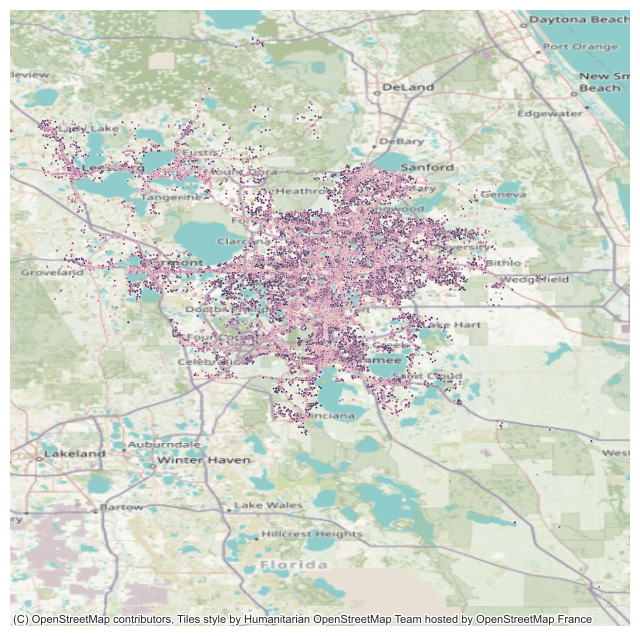

In [96]:
x = pois.join(poi_segregation, on="ID_STORE").filter(pl.col("TOTAL_VISITORS") >= 1000)
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x, x="LONGITUDE", y="LATITUDE", hue="INCOME_SEGREGATION", s=2, legend=False, ax=ax)
cx.add_basemap(ax, zoom='auto', crs='EPSG:4326')
ax.set_axis_off()

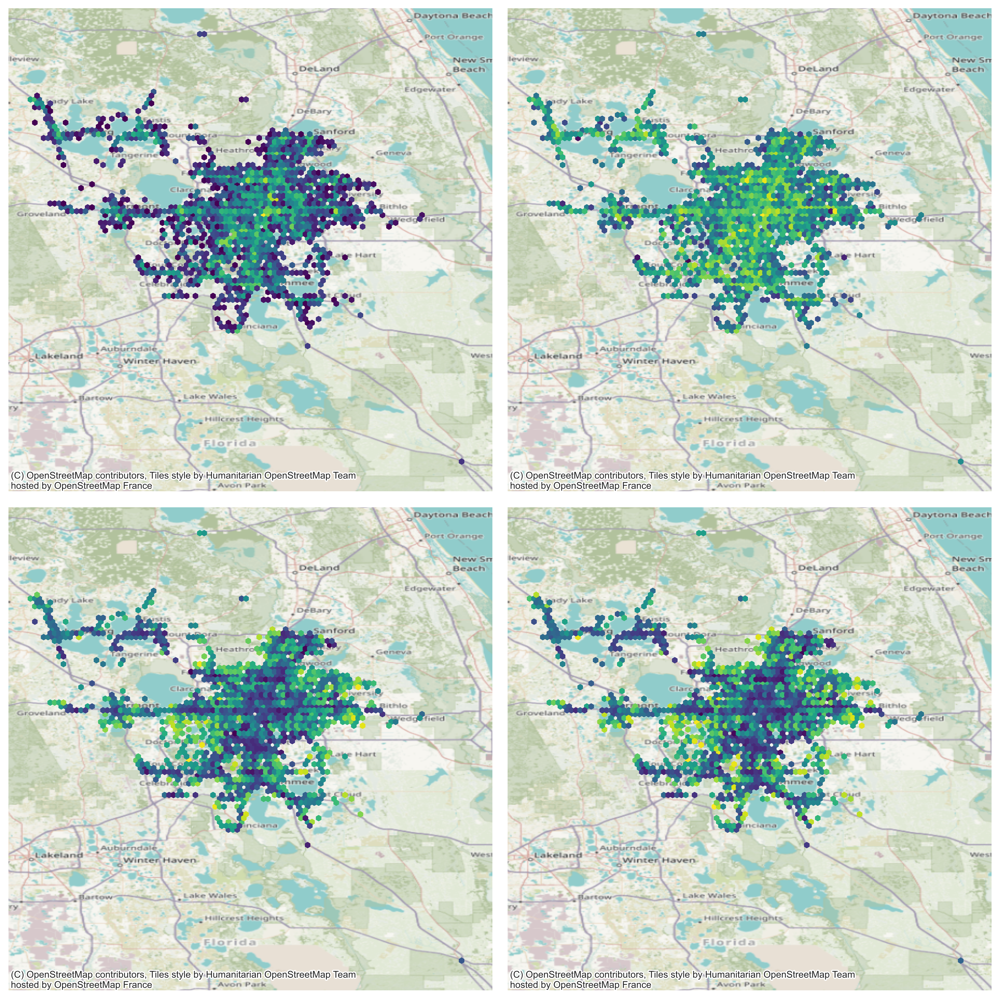

In [125]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=400)
axes = axes.flatten()

hb = axes[0].hexbin(
    x["LONGITUDE"],
    x["LATITUDE"],
    gridsize=100,
    mincnt=5,
    cmap="viridis",
    bins="log"
)

axes[1].hexbin(
    x["LONGITUDE"],
    x["LATITUDE"],
    C=x["TOTAL_VISITORS"],
    reduce_C_function=np.sum,
    gridsize=100,
    mincnt=5,
    cmap="viridis",
    bins="log"
)

axes[2].hexbin(
    x["LONGITUDE"],
    x["LATITUDE"],
    C=x["INCOME_SEGREGATION"],
    reduce_C_function=np.mean,
    gridsize=100,
    mincnt=5,
    cmap="viridis",
)

axes[3].hexbin(
    x["LONGITUDE"],
    x["LATITUDE"],
    C=x["INCOME_SEGREGATION"],
    reduce_C_function=np.median,
    gridsize=100,
    mincnt=5,
    cmap="viridis",
)

for ax in axes:
    cx.add_basemap(ax, crs="EPSG:4326")
    ax.set_axis_off()
fig.tight_layout()

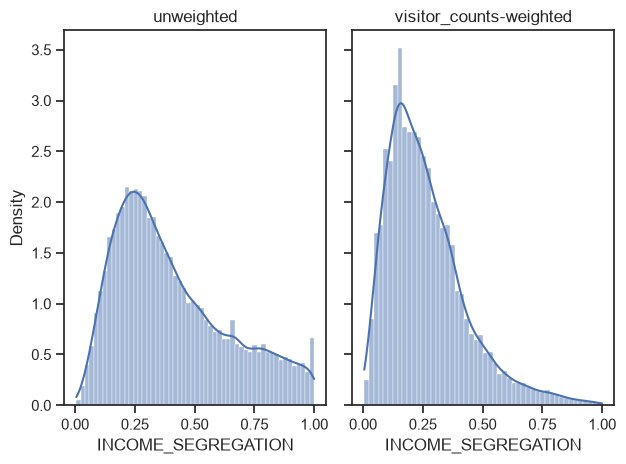

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)
sns.histplot(
    x, 
    x="INCOME_SEGREGATION", 
    kde=True, 
    ax=ax1,
    stat="density"
)
sns.histplot(
    x, 
    x="INCOME_SEGREGATION", 
    weights="TOTAL_VISITORS", 
    kde=True, 
    bins=50,
    ax=ax2,
    stat="density"
)
ax1.set_title("unweighted")
ax2.set_title("visitor_counts-weighted")
fig.tight_layout()

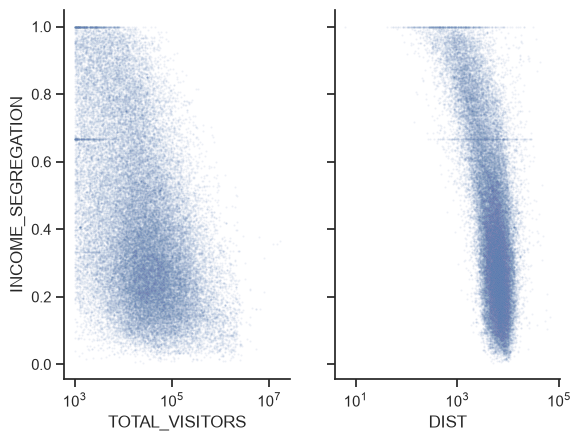

In [129]:
fig, axes = plt.subplots(1, 2, sharey=True)
sns.scatterplot(
    x,
    x="TOTAL_VISITORS",
    y="INCOME_SEGREGATION",
    s=2,
    alpha=0.1,
    ax=axes[0],
)
sns.scatterplot(
    x,
    x="DIST",
    y="INCOME_SEGREGATION",
    s=2,
    alpha=0.1,
    ax=axes[1],
)

for ax in axes:
    ax.set_xscale("log")
sns.despine()

<Axes: xlabel='INCOME_SEGREGATION', ylabel='TOP_CATEGORY'>

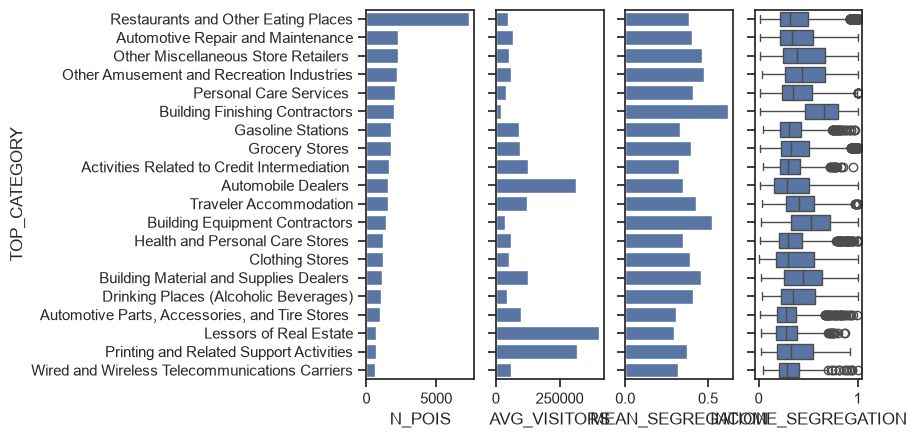

In [210]:
category_summary = (
    x.group_by("TOP_CATEGORY")
    .agg(
        pl.len().alias("N_POIS"),
        pl.col("INCOME_SEGREGATION").median().alias("MEDIAN_SEGREGATION"),
        pl.col("INCOME_SEGREGATION").mean().alias("MEAN_SEGREGATION"),
        pl.col("TOTAL_VISITORS").sum().alias("TOTAL_VISITORS"),
        pl.col("TOTAL_VISITORS").mean().alias("AVG_VISITORS"),
        ((pl.col("DIST") * pl.col("TOTAL_VISITORS")).sum() / pl.col("TOTAL_VISITORS").sum()).alias("DIST")
    )
    .filter(pl.col("N_POIS") >= 30)
    .sort("MEDIAN_SEGREGATION", descending=True)
)
category_summary_top = category_summary.sort("N_POIS", descending=True)[:20]
fig, axes = plt.subplots(1, 4, sharey=True)
sns.barplot(
    category_summary_top,
    y="TOP_CATEGORY", 
    x="N_POIS",
    ax=axes[0]
)
sns.barplot(
    category_summary_top,
    y="TOP_CATEGORY", 
    x="AVG_VISITORS",
    ax=axes[1]
)
sns.barplot(
    category_summary_top,
    y="TOP_CATEGORY", 
    x="MEAN_SEGREGATION",
    ax=axes[2]
)
top_cats = set(category_summary_top["TOP_CATEGORY"].to_list())
sns.boxplot(
    x.filter(pl.col("TOP_CATEGORY").is_in(top_cats)).join(category_summary_top, on="TOP_CATEGORY").sort("TOTAL_VISITORS_right", descending=True), 
    y="TOP_CATEGORY", 
    x="INCOME_SEGREGATION",
    ax=axes[3]
)

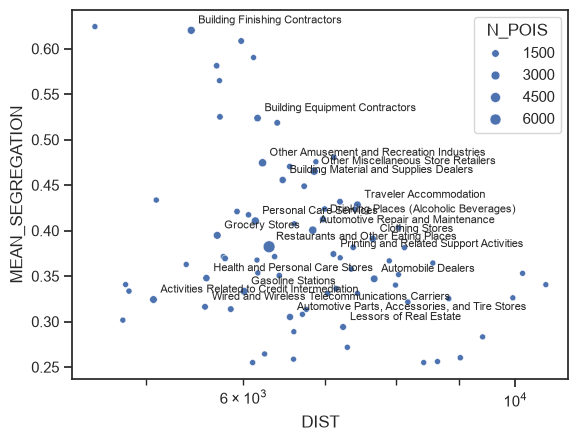

In [211]:
fig, ax = plt.subplots()
sns.scatterplot(
    category_summary,
    x="DIST",
    y="MEAN_SEGREGATION",
    size="N_POIS",
    ax=ax
)
ax.set(
    xscale="log",
)

for row in category_summary_top.iter_rows(named=True):
    ax.annotate(
        row["TOP_CATEGORY"],
        xy=(row["DIST"], row["MEAN_SEGREGATION"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

<Axes: ylabel='HOME_INCOME_GROUP'>

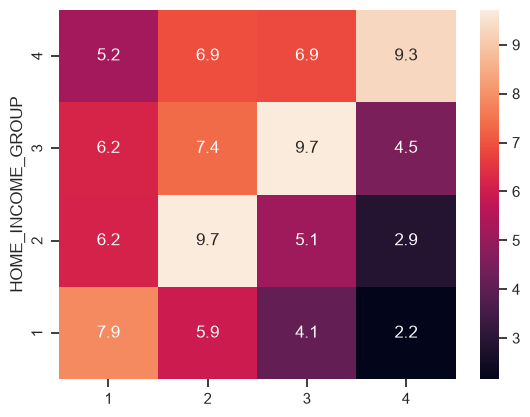

In [172]:
pivot = (
    df.group_by("HOME_INCOME_GROUP", "POI_INCOME_GROUP")
    .agg(pl.col("VISITOR_COUNTS").cast(pl.Float64).sum())
    .with_columns(pct=pl.col("VISITOR_COUNTS") / pl.col("VISITOR_COUNTS").sum() * 100)
    .pivot(
        on="POI_INCOME_GROUP",
        index="HOME_INCOME_GROUP",
        values="pct",
        sort_columns=True,
    )
    .sort("HOME_INCOME_GROUP", descending=True)
    .fill_null(0)
)

sns.heatmap(
    pivot.to_pandas().set_index("HOME_INCOME_GROUP"),
    annot=True,
    fmt=".1f",
)

<Axes: xlabel='POI_INCOME_GROUP', ylabel='VISITOR_COUNTS'>

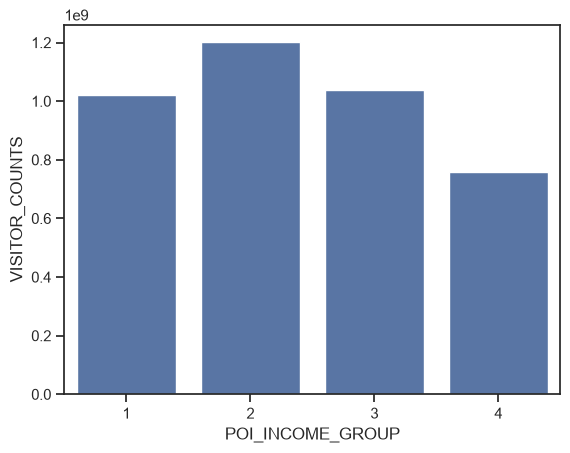

In [176]:
sns.barplot(
    df.group_by("POI_INCOME_GROUP").agg(pl.col("VISITOR_COUNTS").sum()),
    x="POI_INCOME_GROUP",
    y="VISITOR_COUNTS"
)

<Axes: xlabel='POI_INCOME_GROUP', ylabel='ID_STORE'>

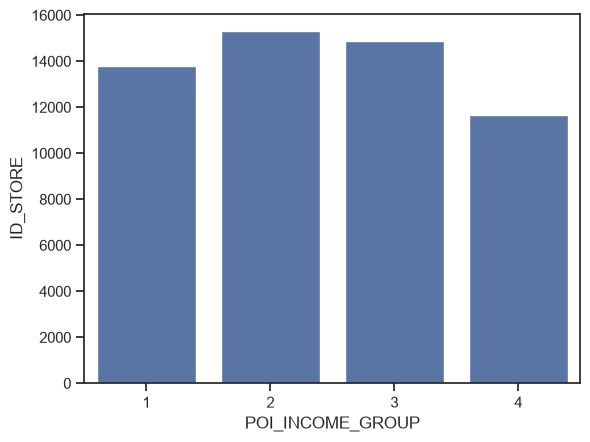

In [215]:
sns.barplot(
    df.group_by("POI_INCOME_GROUP").agg(pl.col("ID_STORE").n_unique()),
    x="POI_INCOME_GROUP",
    y="ID_STORE"
)

## Time dependant segregation

In [20]:
poi_segregation_over_time = (
    df
    .filter(
        pl.col("HOME_INCOME_GROUP").is_not_null()
        & pl.col("VISITOR_COUNTS").is_not_null()
        & (pl.col("VISITOR_COUNTS") >= 0)
    )
    .group_by(["DATE_RANGE_START", "ID_STORE", "HOME_INCOME_GROUP"])
    .agg(
        pl.col("VISITOR_COUNTS").sum().alias("QUARTILE_VISITORS")
    )
    .with_columns(
        pl.col("QUARTILE_VISITORS")
        .sum()
        .over("DATE_RANGE_START", "ID_STORE")
        .alias("TOTAL_VISITORS")
    )
    .filter(pl.col("TOTAL_VISITORS") > 0)
    .with_columns(
        (
            pl.col("QUARTILE_VISITORS")
            / pl.col("TOTAL_VISITORS")
        ).alias("TAU")
    )
    .group_by("DATE_RANGE_START", "ID_STORE")
    .agg(
        pl.col("TOTAL_VISITORS").first(),

        (
            (2 / 3)
            * (
                (pl.col("TAU") - 0.25).abs().sum()
                + (
                    4 - pl.col("HOME_INCOME_GROUP").n_unique()
                ) * 0.25
            )
        ).alias("INCOME_SEGREGATION")
    )
    .sort("DATE_RANGE_START")
)

(0.0, 1.0)

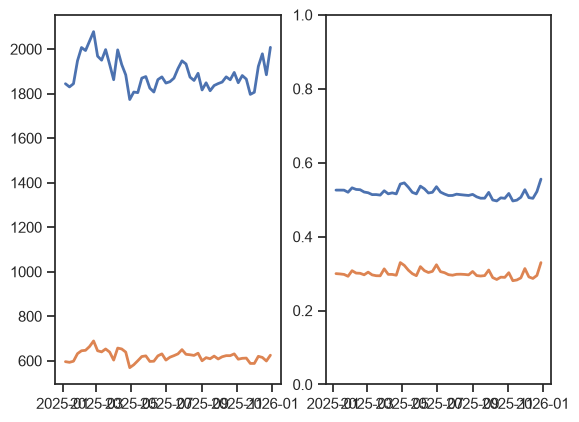

In [21]:
fig, axes = plt.subplots(1, 2, sharex=True)
poi_segregation_over_time_agg = poi_segregation_over_time.group_by("DATE_RANGE_START").agg(
    pl.col("TOTAL_VISITORS").mean(),
    pl.col("TOTAL_VISITORS").median().alias("TOTAL_VISITORS_MEDIAN"),
    pl.col("INCOME_SEGREGATION").mean(),
    (
        (pl.col("INCOME_SEGREGATION") * pl.col("TOTAL_VISITORS")).sum() / pl.col("TOTAL_VISITORS").sum()
    ).alias("INCOME_SEGREGATION_WEIGHTED")
)

axes[0].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["TOTAL_VISITORS"], lw=2, zorder=2)
axes[0].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["TOTAL_VISITORS_MEDIAN"], lw=2, zorder=2)
axes[1].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["INCOME_SEGREGATION"], lw=2, zorder=2)
axes[1].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["INCOME_SEGREGATION_WEIGHTED"], lw=2, zorder=2)

axes[1].set_ylim(0, 1)

In [22]:
seg_time = (
    poi_segregation_over_time
    .sort(["ID_STORE", "DATE_RANGE_START"])
    .with_columns(
        pl.col("INCOME_SEGREGATION")
        .shift(1)
        .over("ID_STORE")
        .alias("SEGREGATION_LAG1"),

        pl.col("DATE_RANGE_START")
        .shift(1)
        .over("ID_STORE")
        .alias("DATE_LAG1"),
    )
    .with_columns(
        (
            pl.col("INCOME_SEGREGATION")
            - pl.col("SEGREGATION_LAG1")
        ).alias("CHANGE"),

        (
            pl.col("INCOME_SEGREGATION")
            - pl.col("SEGREGATION_LAG1")
        ).abs().alias("ABS_CHANGE"),
    )
)

In [24]:
poi_stability = (
    seg_time
    .filter(pl.col("SEGREGATION_LAG1").is_not_null())
    .group_by("ID_STORE")
    .agg(
        pl.len().alias("N_TRANSITIONS"),

        pl.corr(
            "INCOME_SEGREGATION",
            "SEGREGATION_LAG1"
        ).alias("AUTOCORR_LAG1"),

        pl.col("ABS_CHANGE")
        .mean()
        .alias("MEAN_ABS_CHANGE"),

        pl.col("ABS_CHANGE")
        .median()
        .alias("MEDIAN_ABS_CHANGE"),

        pl.col("CHANGE")
        .std()
        .alias("SD_CHANGE"),

        pl.col("INCOME_SEGREGATION")
        .mean()
        .alias("MEAN_SEGREGATION"),

        pl.col("INCOME_SEGREGATION")
        .std()
        .alias("SD_SEGREGATION"),

        pl.col("TOTAL_VISITORS")
        .sum()
        .alias("TOTAL_VISITORS_ALL_PERIODS"),
    )
)

<Axes: xlabel='AUTOCORR_LAG1', ylabel='Count'>

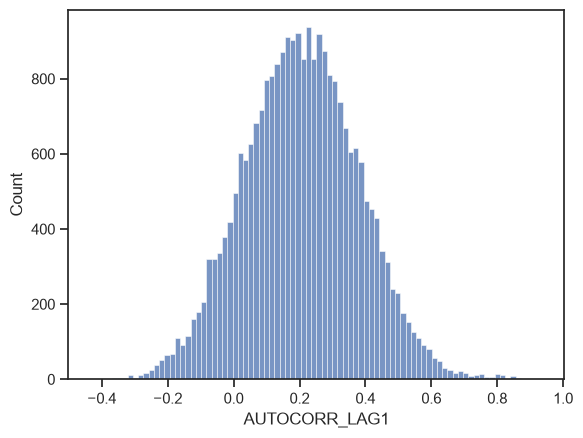

In [26]:
sns.histplot(poi_stability.filter(pl.col("N_TRANSITIONS") == 51), x="AUTOCORR_LAG1")